**Clustering K-Means (non supervisé)**
Regrouper les événements en profils similaires selon leurs caractéristiques
numériques (`GoldsteinScale`, `AvgTone`, `NumMentions`, `NumSources`).

Objectif : découvrir des patterns que les catégories CAMEO ne capturent pas.

Le modèle final est sauvegardé dans le dossier `models/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_PATH = Path('..') / 'data' / 'processed' / 'events_cleaned.csv'
MODEL_DIR = Path('..') / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Chargement des données depuis : {DATA_PATH}')
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'✅ Events chargé  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Chargement des données depuis : ..\data\processed\events_cleaned.csv
✅ Events chargé  : 27,317 lignes × 46 colonnes


## Préparation des données
Nous utilisons les mêmes features et la cible `QuadClass` pour la classification.

QuadClass représente les catégories d'évenements répertorié dans l'actualité béninoise

In [2]:
ML_FEATURES = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources']
ml_cols = ML_FEATURES + ['QuadClass', 'QuadLabel']
ml_cols_ok = [c for c in ml_cols if c in df.columns]

df_ml = df[ml_cols_ok].dropna(subset=ML_FEATURES + ['QuadClass']).copy()
q99 = df_ml['NumMentions'].quantile(0.99)
df_ml = df_ml[df_ml['NumMentions'] <= q99]

print(f'Dataset ML : {len(df_ml):,} événements')
print('Features utilisées :', ML_FEATURES)
print('\nDistribution QuadClass :')
print(df_ml['QuadClass'].value_counts().sort_index().to_string())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[ML_FEATURES])
print('\n✅ Features normalisées (StandardScaler)')

Dataset ML : 27,268 événements
Features utilisées : ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources']

Distribution QuadClass :
QuadClass
1    17564
2     2750
3     3257
4     3697

✅ Features normalisées (StandardScaler)


## Entraînement du modèle Random Forest

In [3]:
X = pd.DataFrame(X_scaled, columns=ML_FEATURES)
y = df_ml['QuadClass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy = (y_pred == y_test).mean()
print(f'Accuracy : {accuracy:.3f}')
print('\nRapport de classification :')
quad_names = {1: 'Coop. verbale', 2: 'Coop. matérielle', 3: 'Conflit verbal', 4: 'Conflit matériel'}
target_names = [quad_names.get(c, str(c)) for c in sorted(y.unique())]
print(classification_report(y_test, y_pred, target_names=target_names))

Train : 21,814 | Test : 5,454
Accuracy : 0.935

Rapport de classification :
                  precision    recall  f1-score   support

   Coop. verbale       0.99      0.96      0.98      3513
Coop. matérielle       0.79      0.80      0.79       550
  Conflit verbal       0.82      0.88      0.85       651
Conflit matériel       0.90      0.95      0.93       740

        accuracy                           0.93      5454
       macro avg       0.88      0.90      0.89      5454
    weighted avg       0.94      0.93      0.94      5454



## Analyse des résultats
Matrice de confusion et importance des features.

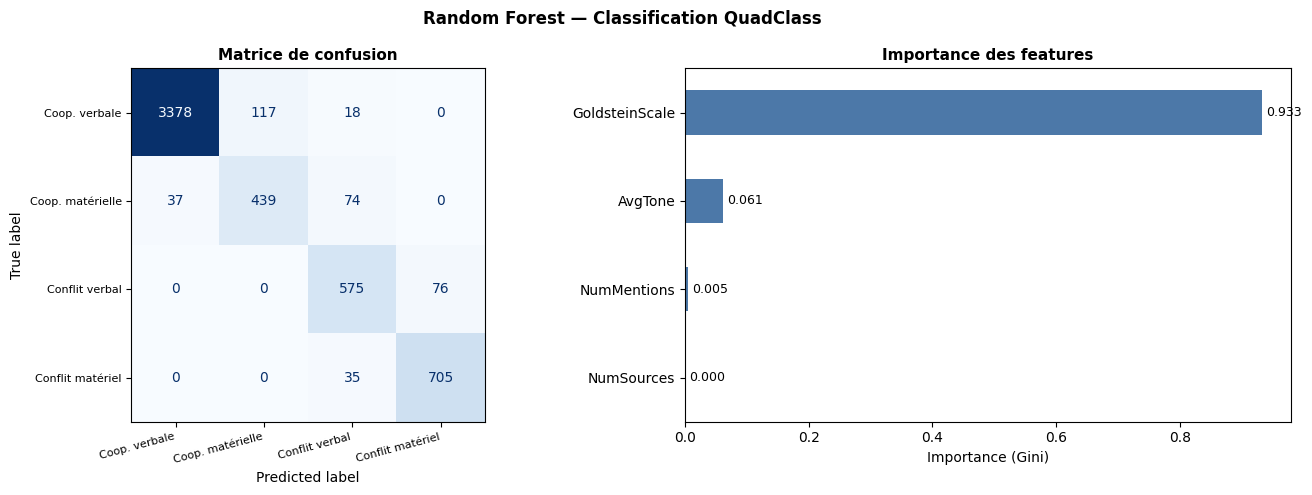


Interprétation :
   Feature la plus discriminante : GoldsteinScale
   Le GoldsteinScale et l'AvgTone sont souvent les signaux les plus forts pour distinguer un événement coopératif d'un événement conflictuel.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion', fontsize=11, fontweight='bold')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=8)
plt.setp(axes[0].yaxis.get_majorticklabels(), fontsize=8)

feat_imp = pd.Series(rf.feature_importances_, index=ML_FEATURES).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='#4C78A8')
axes[1].set_title('Importance des features', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance (Gini)')
axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=3, fontsize=9)

plt.suptitle('Random Forest — Classification QuadClass', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterprétation :')
print(f'   Feature la plus discriminante : {feat_imp.index[-1]}')
print('   Le GoldsteinScale et l\'AvgTone sont souvent les signaux les plus forts pour distinguer un événement coopératif d\'un événement conflictuel.')

## Sauvegarde du modèle
Le classifieur Random Forest final et le scaler sont sauvegardés dans le dossier `models/`.

In [6]:
MODEL_SUBDIR = MODEL_DIR / 'classification'
MODEL_SUBDIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_SUBDIR / 'rf_quadclass_model.pkl'
SCALER_PATH = MODEL_SUBDIR / 'rf_quadclass_scaler.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(rf, f)
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

print(f'Modèle sauvegardé : {MODEL_PATH}')
print(f'Scaler sauvegardé : {SCALER_PATH}')

Modèle sauvegardé : ..\models\classification\rf_quadclass_model.pkl
Scaler sauvegardé : ..\models\classification\rf_quadclass_scaler.pkl
